In [2]:
# Importation des librairies

import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency                   #CHI2
from scipy.stats import f_oneway                           #ANOVA
from scipy.stats import pointbiserialr

from sklearn.dummy import DummyClassifier
from sklearn.experimental import enable_iterative_imputer  # Nécessaire pour activer l'IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb


In [3]:
df = pd.read_csv("data/cleaned_data.csv")
df.head(3)

,State,BankState,NAICS,NoEmp,NewExist,RetainedJob,CreateJob,UrbanRural,RevLineCr,ApprovalFY,Recession,Term,FranchiseCode,DisbursementGross,GrAppv,SBA_Appv,LowDoc,MIS_Status
0,IN,OH,45,4,2.0,0,0,0,0.0,1997,0,84,1,60000.0,60000.0,48000.0,1.0,1
1,IN,IN,72,2,2.0,0,0,0,0.0,1997,0,60,1,40000.0,40000.0,32000.0,1.0,1
2,IN,IN,62,7,1.0,0,0,0,0.0,1997,0,180,1,287000.0,287000.0,215250.0,0.0,1


In [4]:
encoder = OneHotEncoder(sparse_output=False, drop='first')
# Encodage de 'State'
state_encoded = encoder.fit_transform(df[['State']])
state_df = pd.DataFrame(state_encoded, columns=encoder.get_feature_names_out(['State']))

# Encodage de 'BankState'
bankstate_encoded = encoder.fit_transform(df[['BankState']])
bankstate_df = pd.DataFrame(bankstate_encoded, columns=encoder.get_feature_names_out(['BankState']))

# Fusion avec le DataFrame original (en supprimant les colonnes encodées)
df = pd.concat([df.drop(['State', 'BankState'], axis=1), state_df, bankstate_df], axis=1)


In [5]:
df.head(3)

,NAICS,NoEmp,NewExist,RetainedJob,CreateJob,UrbanRural,RevLineCr,ApprovalFY,Recession,Term,...,BankState_TX,BankState_UT,BankState_VA,BankState_VI,BankState_VT,BankState_WA,BankState_WI,BankState_WV,BankState_WY,BankState_nan
0,45,4,2.0,0,0,0,0.0,1997,0,84,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,72,2,2.0,0,0,0,0.0,1997,0,60,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,62,7,1.0,0,0,0,0.0,1997,0,180,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Préparation des données

In [6]:
X = df.drop('MIS_Status', axis=1)
y = df['MIS_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True, test_size=0.1, random_state=42, stratify=y)

# Standardisation des données (mise à l'échelle)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# dummy_clf = DummyClassifier(strategy="most_frequent")  # Il prédit toujours la classe majoritaire
# dummy_clf.fit(X_train, y_train)
# y_dummy_pred = dummy_clf.predict(X_test)

# # Évaluer la performance
# dummy_acc = accuracy_score(y_test, y_dummy_pred)
# print(f"Accuracy du DummyClassifier : {dummy_acc:.2f}")

# log_reg = LogisticRegression()
# log_reg.fit(X_train, y_train)
# y_log_reg_pred = log_reg.predict(X_test)

# # Évaluer la performance
# log_reg_acc = accuracy_score(y_test, y_log_reg_pred)
# print(f"Accuracy de la Régression Logistique : {log_reg_acc:.2f}")

Accuracy du DummyClassifier : 0.82


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [6]:


# Initialisation du modèle de régression logistique
log_reg_model = LogisticRegression()

# Entraînement du modèle
log_reg_model.fit(X_train_scaled, y_train)
                  


# Prédictions sur l'ensemble de test
y_pred = log_reg_model.predict(X_test_scaled)

# Évaluation du modèle
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Affichage des résultats
print(f"Accuracy : {accuracy}")
print(f"Confusion Matrix :\n{conf_matrix}")
print(f"Classification Report :\n{class_report}")

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

AUC: 0.84


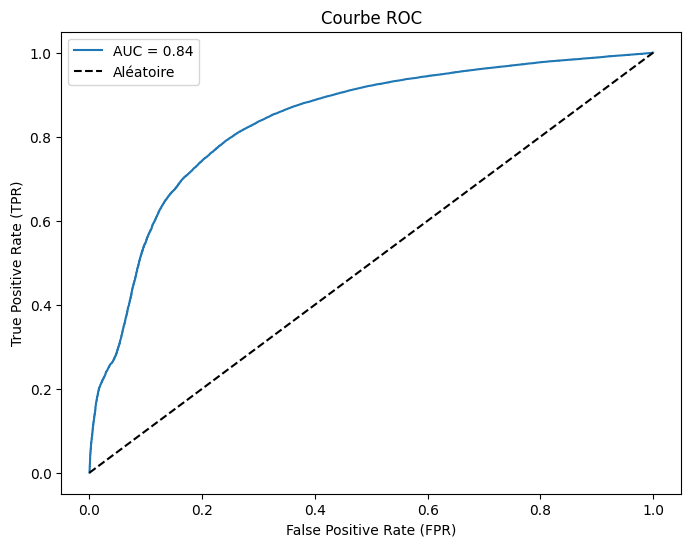

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Obtenir les probabilités prédites pour la classe positive (1)
y_prob = log_reg_model.predict_proba(X_test_scaled)[:, 1]  

# Calcul du score AUC-ROC
auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC: {auc_score:.2f}")

# Tracé de la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], 'k--', label="Aléatoire")  # Courbe d'un modèle aléatoire
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Courbe ROC')
plt.legend()
plt.show()


# RANDOM FOREST

In [9]:


forest = RandomForestClassifier(n_estimators=100)
forest.fit(X_train, y_train)
forest_pred = forest.predict(X_test)
score = (accuracy_score(y_test,forest_pred) * 100)
print('Random Forest Accuracy: %r' % round(score,2), '%')



Random Forest Accuracy: 94.92 %


# XGBOOST

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.base import BaseEstimator, TransformerMixin

class CustomTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Fit logic here
        return self

    def transform(self, X):
        # Transformation logic here
        return X

# 1️⃣ Chargement des données
df = pd.read_csv("data/cleaned_data.csv")

# 2️⃣ Séparation des features (X) et de la cible (y)
target = "Default"
X = df.drop('MIS_Status', axis=1)
y = df['MIS_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True, test_size=0.1, random_state=42, stratify=y)

# 3️⃣ Identification des types de colonnes
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object"]).columns

# 4️⃣ Prétraitement des données
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),  # Normalisation des variables numériques
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)  # Encodage OneHot pour les catégoriques
])

# 5️⃣ Pipeline avec XGBoost
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, use_label_encoder=False, eval_metric="logloss"))
])

# 6️⃣ Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7️⃣ Entraînement du modèle
pipeline.fit(X_train, y_train)

# 8️⃣ Prédictions et évaluation
y_pred = pipeline.predict(X_test)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Classification Report :\n", classification_report(y_test, y_pred))


/home/antoine/Documents/Projets_DEV_IA/Brief04_Classification/Brief04_USSBA_classification/.venv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [16:21:23] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


AttributeError: 'super' object has no attribute '__sklearn_tags__'

In [7]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    num_leaves = 20

    objective='multiclass',  # Type d'objectif, ici classification multiclasses
    num_class=3,             # Nombre de classes (3 classes dans le jeu de données Iris)
    random_state=42,         # Fixer la graine aléatoire pour la reproductibilité
    boosting_type='gbdt',    # Type de boosting (Gradient Boosting Decision Tree)
    num_leaves=31,           # Nombre de feuilles dans chaque arbre (paramètre de contrôle de la profondeur de l'arbre)
    max_depth=-1,            # Profondeur maximale des arbres (ici, aucune limite)
    learning_rate=0.1,       # Taux d'apprentissage
    n_estimators=100,        # Nombre d'arbres
    subsample=0.8,           # Fraction des échantillons à utiliser pour chaque arbre (réduit le surapprentissage)
    colsample_bytree=0.8     # Fraction des features à utiliser pour chaque arbre
)

lgbm.fit(X, y)

y_pred = lgbm.predict(X_test)

[LightGBM] [Fatal] Number of classes should be specified and greater than 1 for multiclass training


LightGBMError: Number of classes should be specified and greater than 1 for multiclass training

In [6]:
x.dtype()

NameError: name 'x' is not defined